# <span style="color:darkblue"> QTM 151 - Quiz 4 </span>

## Try to submit as an HTML file

<font size="5"> 

Print your name below

In [1]:
# Write your answer here

print("Joanna Yao")


Joanna Yao


<font size = "5" >
This quiz is open book 

- You can use the lecture notes
- You will get partial credit for attempting the questions
- To get full credit, the code should run as intended
- You should <span style="color:red"> NOT </span> communicate with other students

Print the following message: <br>

"I will abide by Emory's code of conduct"


In [3]:
# Write your answer here:

print("I will abide by Emory's code of conduct")

I will abide by Emory's code of conduct


<font size = "5">

Import the libraries "matplotlib.pyplot" and "pandas"

In [2]:
# Write your answer here

import pandas as pd
import matplotlib.pyplot as plt


<font size = "5">

In this quiz you will work with data on exchange rates, <br>
for the following currencies:

- 1 euro (EUR) to dollar (USD)
- 1 pound (GPB) to dollar (USD).


<font size = "5">

(a) Import and parse dates

<font size = "3">

- Import the dataset "currencies.csv"
- Parse the "date_string" column with ```pd.to_datetime()```
- To get full points, set the "format" option using wildcards as in Lecture 16.


In [4]:
# Write your own code
currencies=pd.read_csv("data_raw/currencies.csv")
currencies['date_string']=pd.to_datetime(currencies["date_string"],format="%A, %b %d, %Y")

<font size = "5">

(b) Plot multiple time series

<font size = "3">

- Create a line plot plot which has the "gbp_to_usd" and "eur_to_usd" on the y-axis <br>
and the date on the x-axis
- Label the x-axis, the y-axis, and the title
- Add a legend and set the names to "1 Euro to USD" and "1 GPB to USD"

Hint: See Lecture 18 for how to plot multiple columns <br>
Hint: Remember to include the legend names as a list ```[...]```


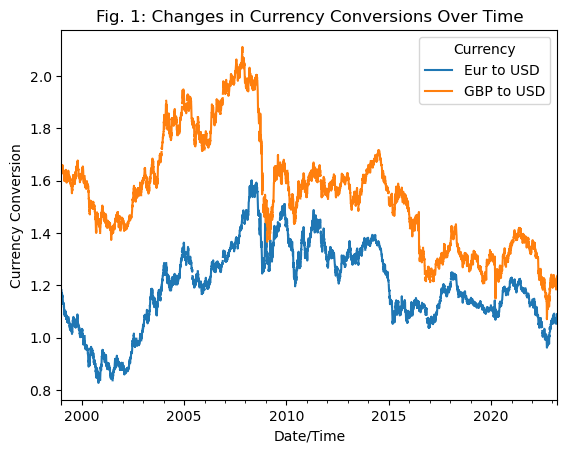

In [12]:
# Write your own code


currencies[["date_string","gbp_to_usd","eur_to_usd"]].set_index("date_string").plot()
plt.xlabel("Date/Time")
plt.ylabel("Currency Conversion")
plt.title("Fig. 1: Changes in Currency Conversions Over Time")
plt.legend(labels=["Eur to USD","GBP to USD"],title="Currency")
plt.show()






<font size = "5">

(c) Compute growth rates

<font size = "3">

- Calculate a new column "growth_euro" which computes the percentage daily <br>
growth rate of "eur_to_usd".

Hint: Use ```.diff()``` and ```.shift(1)```

In [10]:
# Write your own code

currencies["diff_euro"]=currencies["eur_to_usd"].diff()
currencies["lag_euro"]=currencies["eur_to_usd"].shift(1)
currencies["growth_euro"]=(currencies["diff_euro"]/currencies["lag_euro"])*100
currencies


,date_string,eur_to_usd,gbp_to_usd,growth_euro,diff_euro,lag_euro
0,1999-01-04,1.6581,1.1812,NaN,NaN,NaN
1,1999-01-05,1.6566,1.1760,-0.090465,-0.0015,1.6581
2,1999-01-06,1.6547,1.1636,-0.114693,-0.0019,1.6566
3,1999-01-07,1.6495,1.1672,-0.314256,-0.0052,1.6547
4,1999-01-08,1.6405,1.1554,-0.545620,-0.0090,1.6495
...,...,...,...,...,...,...
6320,2023-03-27,1.2278,1.0789,0.433538,0.0053,1.2225
6321,2023-03-28,1.2341,1.0844,0.513113,0.0063,1.2278
6322,2023-03-29,1.2313,1.0826,-0.226886,-0.0028,1.2341
6323,2023-03-30,1.2368,1.0899,0.446682,0.0055,1.2313


<font size = "5">

(d) Flag subset of data and plot

<font size = "3">

- Create a boolean colum (True/False) "bool_cond" which checks whether <br>
"growth_euro" had a value greater than 2 or less than -2
- Generate a line plot with the "growth_euro" series, label the axes and the title
- Use the command ```plt.fill_between()``` as in Lecture 18 to create a shaded region <br>
for time periods where "bool_cond" is true.



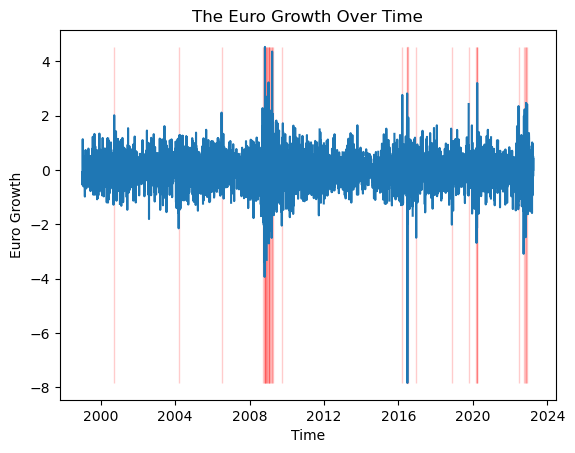

In [47]:
# Write your own code

currencies["bool_cond"]= (currencies["growth_euro"] > 2) | (currencies["growth_euro"] < -2)

plt.plot("date_string","growth_euro",data=currencies)
plt.xlabel("Time")
plt.ylabel("Euro Growth")
plt.title("The Euro Growth Over Time")

vec_y=currencies["growth_euro"]
plt.fill_between(x=currencies["date_string"],
                 y1 = vec_y.min(),
                 y2 = vec_y.max(),
                 where = currencies["bool_cond"],
                 alpha = 0.2,color = "red")

plt.show()


<font size = "5">

(e) Aggregate dataset by time period

<font size = "3">

- Create an object "month_config" that uses ```pd.Grouper()```, setting the key to <br>
the column "date" and freq to "m" (month)
- Follow the instructions in Lecture 16 to compute an aggregate dataset <br>
by month which computes the standard deviation of "eur_to_usd"
- Display the dataset




In [32]:
# Write your own code

month_config=pd.Grouper(key='date_string',freq='m')

monthlydata=(currencies
             .groupby(month_config)
             .agg(eur_to_usd_sd=('eur_to_usd','std'))
             .reset_index())

monthlydata

/var/folders/32/3w34rzbd3p5bt11qlfrhk6w00000gn/T/ipykernel_71684/2835673725.py:3: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'ME' instead.
  month_config=pd.Grouper(key='date_string',freq='m')


,date_string,eur_to_usd_sd
0,1999-01-31,0.007345
1,1999-02-28,0.013345
2,1999-03-31,0.010475
3,1999-04-30,0.006172
4,1999-05-31,0.013046
...,...,...
286,2022-11-30,0.027308
287,2022-12-31,0.011389
288,2023-01-31,0.015046
289,2023-02-28,0.008972


<font size = "5">

(f) Convert a dataset to long format

<font size = "3">

- Convert the currencies dataset to long format using the following inputs

```
var_name   = "type",
value_name = "exchange_rate",
id_vars    = "date",
value_vars = ["eur_to_usd","gbp_to_usd"]
```

- Display the dataset

Hint: See Lecture 18 for details on ```pd.melt()```

In [29]:
# Write your own code

currencies_long=pd.melt(currencies,var_name="type",value_name="exchange_rate",id_vars="date_string",value_vars=['eur_to_usd','gbp_to_usd'])
currencies_long

,date_string,type,exchange_rate
0,1999-01-04,eur_to_usd,1.6581
1,1999-01-05,eur_to_usd,1.6566
2,1999-01-06,eur_to_usd,1.6547
3,1999-01-07,eur_to_usd,1.6495
4,1999-01-08,eur_to_usd,1.6405
...,...,...,...
12645,2023-03-27,gbp_to_usd,1.0789
12646,2023-03-28,gbp_to_usd,1.0844
12647,2023-03-29,gbp_to_usd,1.0826
12648,2023-03-30,gbp_to_usd,1.0899
